In [ ]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
data_dir = Path("/home/qmoreau/gogo_bursts/stat_output")
pc       = 12
epoch    = "RESP"

TERTILES       = [1, 2, 3]
BURST_LABELS   = {1: "Burst type 1", 2: "Burst type 2", 3: "Burst type 3"}
BURST_CMAP     = matplotlib.colormaps["winter"]
BURST_COLORS   = {t: BURST_CMAP(0.15 + 0.7 * (t - 1) / (len(TERTILES) - 1)) for t in TERTILES}


Saved → /home/qmoreau/gogo_bursts/stat_output/PC_12_RESP_CrossTrial_Coefficients_grid.pdf


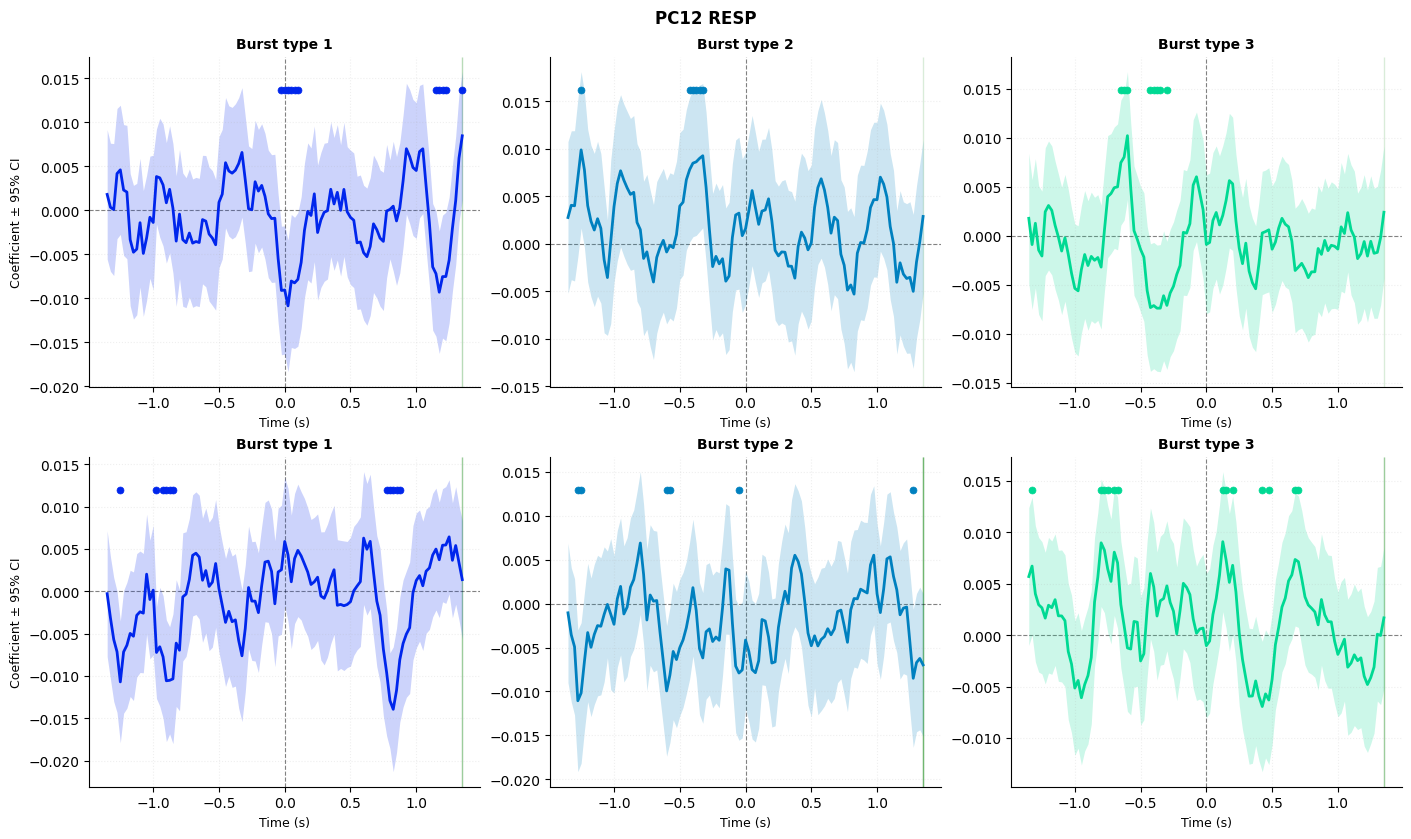

In [27]:

coefs = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_TimeResolved_Coefs.csv")
windows = pd.read_csv(data_dir / f"PC_{pc}_{epoch}_CrossTrial_RT_windows.csv")


# Figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

factors = ["burst_count", "burst_count:age_c"]
factor_titles = ["Burst main effect", "Burst × Age interaction"]

for row, (factor, factor_title) in enumerate(zip(factors, factor_titles)):
    for col, tertile in enumerate(TERTILES):
        ax = axes[row, col]
        color = BURST_COLORS[tertile]
        
        # Get data for this factor × tertile
        coef_data = coefs[(coefs["factor"] == factor) & (coefs["tertile"] == tertile)].sort_values("time")
        
        if coef_data.empty:
            ax.text(0.5, 0.5, f"No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{BURST_LABELS[tertile]}", fontweight="bold", fontsize=10)
            continue
        
        # Reference lines
        ax.axhline(0, color="k", linestyle="--", linewidth=0.8, zorder=1, alpha=0.5)
        ax.axvline(0, color="k", linestyle="--", linewidth=0.8, zorder=1, alpha=0.5)
        
        # CI band
        ax.fill_between(
            coef_data["time"],
            coef_data["estimate"] - 1.96 * coef_data["se"],
            coef_data["estimate"] + 1.96 * coef_data["se"],
            color=color, alpha=0.20, linewidth=0
        )
        
        # Line 
        ax.plot(coef_data["time"], coef_data["estimate"],
                color=color, linewidth=2.0)
        
        # Significant windows from permutation
        win_data = windows[(windows["factor"] == factor) & (windows["tertile"] == tertile)]
        for _, row_win in win_data.iterrows():
            ax.axvspan(row_win["start"], row_win["end"], alpha=0.15, color="green", zorder=0)
        
        # Draw plot to get axis limits
        ax.set_title(f"{BURST_LABELS[tertile]}", fontweight="bold", fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=9)
        if col == 0:
            ax.set_ylabel("Coefficient ± 95% CI", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, alpha=0.2, linestyle=":")
        
        # Place significant timepoints on a horizontal line at top
        sig = coef_data[coef_data["anova_p"] < 0.05]
        if not sig.empty:
            # Get y-axis range and place stars at 90% of top
            ylim = ax.get_ylim()
            y_pos = ylim[0] + 0.90 * (ylim[1] - ylim[0])
            ax.scatter(sig["time"], [y_pos] * len(sig), color=color, s=100, zorder=10, 
                      marker=".", linewidth=0.5)



fig.suptitle(f"PC{pc} {epoch}", 
             fontweight="bold", fontsize=12, y=1.03)

out_path = data_dir / f"PC_{pc}_{epoch}_CrossTrial_Coefficients_grid.pdf"
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved → {out_path}")
plt.show()